# Beyond Accuracy: Heart Disease Classification on Imbalanced Survey Data

Predicting self-reported heart disease from behavioral, medical, and demographic
features in the CDC BRFSS 2020 survey, and showing why **accuracy is the wrong
metric** when the classes are imbalanced.

**The short version:** four standard classifiers all score ~89% accuracy, but none
beats a model that just predicts "no disease" for everyone, and they detect only
1.5%-15.2% of actual heart disease cases. Two standard fixes (class weighting and
decision-threshold tuning) recover most of that lost sensitivity, raising detection
to roughly two-thirds of cases. The signal was there the whole time; the default
0.5 threshold was hiding it.

**Dataset:** a 3,087-row subset of the [Personal Key Indicators of Heart Disease](https://www.kaggle.com/datasets/kamilpytlak/personal-key-indicators-of-heart-disease)
dataset (derived from BRFSS 2020). Positive cases are 11.7% of records.


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, balanced_accuracy_score, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score, classification_report,
)

RANDOM_STATE = 0
plt.rcParams["figure.figsize"] = (8, 6)

## 2. Load the data

In [2]:
heart_df = pd.read_csv("data/heart_2020_cleaned_edited.csv").dropna()

# Encode the target: Yes -> 1, No -> 0
heart_df["HeartDisease"] = heart_df["HeartDisease"].map({"Yes": 1, "No": 0})

print("Shape:", heart_df.shape)
print()
print(heart_df["HeartDisease"].value_counts())
print()
prevalence = heart_df["HeartDisease"].mean()
print(f"Positive-class prevalence: {prevalence:.3f}  ({heart_df['HeartDisease'].sum()} of {len(heart_df)})")

Shape: (3087, 18)

HeartDisease
0    2726
1     361
Name: count, dtype: int64

Positive-class prevalence: 0.117  (361 of 3087)


In [3]:
heart_df.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,0,16.60,Yes,No,No,3,30,No,Female,55-59,White,Yes,Yes,Very good,5,Yes,No,Yes
1,0,20.34,No,No,Yes,0,0,No,Female,80 or older,White,No,Yes,Very good,7,No,No,No
2,0,26.58,Yes,No,No,20,30,No,Male,65-69,White,Yes,Yes,Fair,8,Yes,No,No
3,0,24.21,No,No,No,0,0,No,Female,75-79,White,No,No,Good,6,No,No,Yes
4,0,23.71,No,No,No,28,0,Yes,Female,40-44,White,No,Yes,Very good,8,No,No,No


## 3. Preprocessing

Split predictors into continuous and categorical, one-hot encode the categorical
ones (dropping the first level of each to avoid redundancy), and recombine.


In [4]:
X = heart_df.drop(["HeartDisease"], axis=1)
y = heart_df["HeartDisease"]

categorical_cols = ["Race", "AgeCategory", "GenHealth", "Sex", "Smoking",
                    "AlcoholDrinking", "Stroke", "DiffWalking", "Diabetic",
                    "PhysicalActivity", "Asthma", "KidneyDisease", "SkinCancer"]

numerical = X.drop(categorical_cols, axis=1)
categorical = X[categorical_cols]

cat_numerical = pd.get_dummies(categorical, drop_first=True)
X = pd.concat([numerical, cat_numerical], axis=1)

print("Feature matrix shape after encoding:", X.shape)
X.head()

Feature matrix shape after encoding: (3087, 37)


,BMI,PhysicalHealth,MentalHealth,SleepTime,Race_Asian,Race_Black,Race_Hispanic,Race_Other,Race_White,AgeCategory_25-29,...,AlcoholDrinking_Yes,Stroke_Yes,DiffWalking_Yes,"Diabetic_No, borderline diabetes",Diabetic_Yes,Diabetic_Yes (during pregnancy),PhysicalActivity_Yes,Asthma_Yes,KidneyDisease_Yes,SkinCancer_Yes
0,16.60,3,30,5,False,False,False,False,True,False,...,False,False,False,False,True,False,True,True,False,True
1,20.34,0,0,7,False,False,False,False,True,False,...,False,True,False,False,False,False,True,False,False,False
2,26.58,20,30,8,False,False,False,False,True,False,...,False,False,False,False,True,False,True,True,False,False
3,24.21,0,0,6,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
4,23.71,28,0,8,False,False,False,False,True,False,...,False,False,True,False,False,False,True,False,False,False


### Quick correlation look (numeric features)

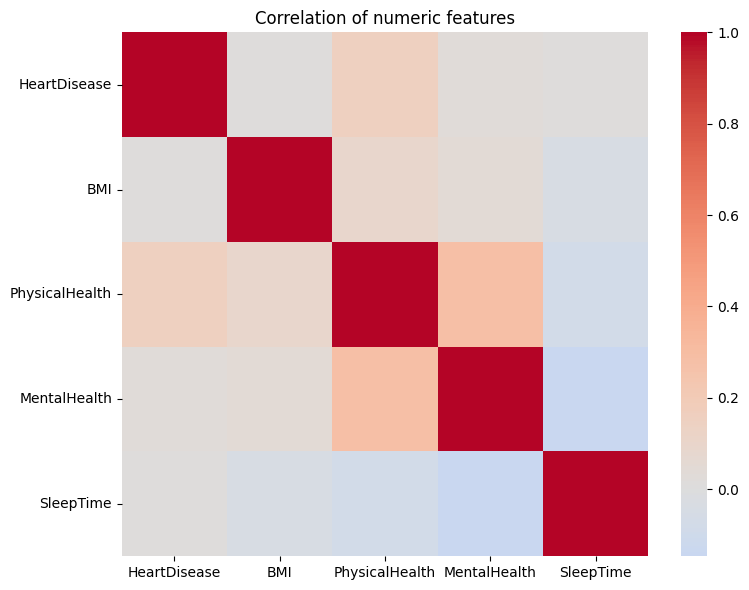

In [5]:
corr = heart_df._get_numeric_data().corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation of numeric features")
plt.tight_layout()
plt.show()

## 4. Train / test split and scaling

80/20 split with a fixed seed. The scaler is fit on the training data only, then
applied to the test data, so no test information leaks into preprocessing.


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

n_pos = int(y_test.sum())
n_neg = int((y_test == 0).sum())
print(f"Test set: {len(y_test)} records  |  {n_pos} positive, {n_neg} negative")
print(f"A 'predict all negative' baseline would score {n_neg/len(y_test)*100:.2f}% accuracy")

Test set: 618 records  |  66 positive, 552 negative
A 'predict all negative' baseline would score 89.32% accuracy


## 5. A metrics helper

Accuracy alone hides everything interesting here, so this reports the full picture:
confusion-matrix counts, sensitivity (recall on the positive class), specificity,
positive-class precision/F1, and balanced accuracy.


In [7]:
def evaluate(name, y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "model": name,
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
        "accuracy": accuracy_score(y_true, y_pred),
        "sensitivity": recall_score(y_true, y_pred, pos_label=1),
        "specificity": recall_score(y_true, y_pred, pos_label=0),
        "precision_pos": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_pos": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "balanced_acc": balanced_accuracy_score(y_true, y_pred),
    }

def show(row):
    print(f"{row['model']:<34} "
          f"TN={row['TN']:>3} FP={row['FP']:>3} FN={row['FN']:>3} TP={row['TP']:>3} | "
          f"acc={row['accuracy']*100:5.2f}%  sens={row['sensitivity']:.3f}  "
          f"spec={row['specificity']:.3f}  F1={row['f1_pos']:.3f}  bal={row['balanced_acc']:.3f}")

## 6. Baseline models (default settings)

Four standard classifiers, all with default hyperparameters. This is the
"out of the box" behavior we want to measure before applying any fixes.


In [8]:
results = []

models = {
    "Logistic Regression":  LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "K-Nearest Neighbors":  KNeighborsClassifier(n_neighbors=5),
    "Random Forest":        RandomForestClassifier(n_estimators=500, random_state=42),
    "Support Vector Machine": svm.SVC(random_state=RANDOM_STATE),
}

for name, clf in models.items():
    clf.fit(X_train, y_train)
    row = evaluate(name, y_test, clf.predict(X_test))
    results.append(row)
    show(row)

# Majority-class baseline for comparison
baseline_pred = np.zeros_like(y_test)
row = evaluate("Majority-class baseline", y_test, baseline_pred)
results.append(row)
show(row)

Logistic Regression                TN=540 FP= 12 FN= 57 TP=  9 | acc=88.83%  sens=0.136  spec=0.978  F1=0.207  bal=0.557
K-Nearest Neighbors                TN=530 FP= 22 FN= 56 TP= 10 | acc=87.38%  sens=0.152  spec=0.960  F1=0.204  bal=0.556


Random Forest                      TN=544 FP=  8 FN= 60 TP=  6 | acc=89.00%  sens=0.091  spec=0.986  F1=0.150  bal=0.538


Support Vector Machine             TN=551 FP=  1 FN= 65 TP=  1 | acc=89.32%  sens=0.015  spec=0.998  F1=0.029  bal=0.507
Majority-class baseline            TN=552 FP=  0 FN= 66 TP=  0 | acc=89.32%  sens=0.000  spec=1.000  F1=0.000  bal=0.500


In [9]:
baseline_df = pd.DataFrame(results).set_index("model")
baseline_df[["TN", "FP", "FN", "TP", "accuracy", "sensitivity",
             "specificity", "f1_pos", "balanced_acc"]].round(3)

,TN,FP,FN,TP,accuracy,sensitivity,specificity,f1_pos,balanced_acc
model,,,,,,,,,
Logistic Regression,540,12,57,9,0.888,0.136,0.978,0.207,0.557
K-Nearest Neighbors,530,22,56,10,0.874,0.152,0.960,0.204,0.556
Random Forest,544,8,60,6,0.890,0.091,0.986,0.150,0.538
Support Vector Machine,551,1,65,1,0.893,0.015,0.998,0.029,0.507
Majority-class baseline,552,0,66,0,0.893,0.000,1.000,0.000,0.500


**Read this table carefully.** Every model lands near 89% accuracy, but:

- The SVM predicts the positive class only twice in 618 records (sensitivity 0.015).
- No model beats the majority-class baseline's 89.32% accuracy.
- Balanced accuracy is barely above 0.50 (chance) for all of them.

This is the *accuracy paradox*: high accuracy, near-useless detection.

In [10]:
# The Random Forest single-split result is representative:
rf = RandomForestClassifier(n_estimators=500, random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=5, scoring="accuracy")
print("Random Forest 5-fold CV accuracy:", np.round(cv_scores, 4))
print(f"Mean: {cv_scores.mean()*100:.2f}%  (std {cv_scores.std()*100:.2f}%)")

Random Forest 5-fold CV accuracy: [0.8835 0.8786 0.8849 0.8817 0.8768]
Mean: 88.11%  (std 0.30%)


### Figure: sensitivity vs specificity (baseline models)

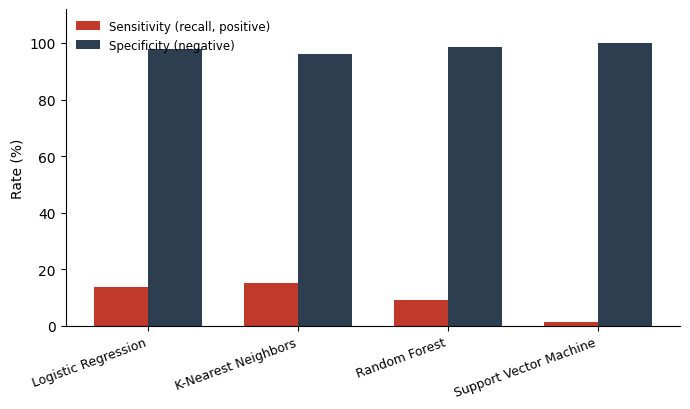

In [11]:
fig, ax = plt.subplots(figsize=(7, 4.2))
plot_df = baseline_df.drop("Majority-class baseline")
x = np.arange(len(plot_df)); w = 0.36
ax.bar(x - w/2, plot_df["sensitivity"]*100, w, label="Sensitivity (recall, positive)", color="#c0392b")
ax.bar(x + w/2, plot_df["specificity"]*100, w, label="Specificity (negative)", color="#2c3e50")
ax.set_xticks(x); ax.set_xticklabels(plot_df.index, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("Rate (%)"); ax.set_ylim(0, 112)
ax.legend(frameon=False, fontsize=8.5)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("figures/sens_spec.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Does the Random Forest actually learn anything?

Thresholded predictions detect few cases, but the *ranking* of predicted
probabilities may still be informative. ROC-AUC measures exactly that.


In [12]:
rf = RandomForestClassifier(n_estimators=500, random_state=42).fit(X_train, y_train)
proba = rf.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, proba)
ap = average_precision_score(y_test, proba)
print(f"Random Forest ROC-AUC: {roc_auc:.3f}")
print(f"Average precision (PR-AUC): {ap:.3f}   (positive prevalence = {y_test.mean():.3f})")

Random Forest ROC-AUC: 0.787
Average precision (PR-AUC): 0.307   (positive prevalence = 0.107)


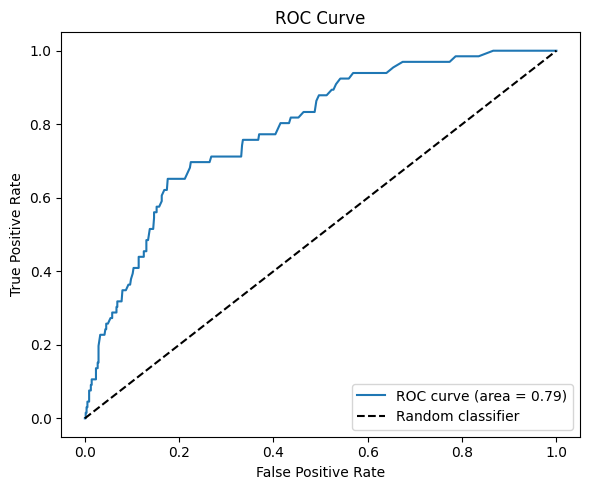

In [13]:
fpr, tpr, thresholds = roc_curve(y_test, proba, pos_label=1)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (area = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], "k--", label="Random classifier")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve"); plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("figures/roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

An AUC of **0.79** is well above the 0.50 of random guessing. So the model *has*
learned real structure, it just isn't expressed at the default 0.5 threshold.
That sets up the two fixes below.

## 8. Fix #1 - Class weighting

`class_weight="balanced"` penalizes errors on the rare positive class in proportion
to its scarcity, pushing the decision boundary toward detecting more positives.


In [14]:
weighted_results = []

weighted_models = {
    "Logistic Regression (balanced)":
        LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Support Vector Machine (balanced)":
        svm.SVC(class_weight="balanced", probability=True, random_state=42),
    "Random Forest (balanced)":
        RandomForestClassifier(n_estimators=500, class_weight="balanced", random_state=42),
}

for name, clf in weighted_models.items():
    clf.fit(X_train, y_train)
    row = evaluate(name, y_test, clf.predict(X_test))
    row["roc_auc"] = roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1])
    weighted_results.append(row)
    show(row)

Logistic Regression (balanced)     TN=399 FP=153 FN= 15 TP= 51 | acc=72.82%  sens=0.773  spec=0.723  F1=0.378  bal=0.748


Support Vector Machine (balanced)  TN=443 FP=109 FN= 25 TP= 41 | acc=78.32%  sens=0.621  spec=0.803  F1=0.380  bal=0.712


Random Forest (balanced)           TN=544 FP=  8 FN= 61 TP=  5 | acc=88.83%  sens=0.076  spec=0.986  F1=0.127  bal=0.531


In [15]:
weighted_df = pd.DataFrame(weighted_results).set_index("model")
weighted_df[["TN", "FP", "FN", "TP", "accuracy", "sensitivity",
             "specificity", "f1_pos", "balanced_acc", "roc_auc"]].round(3)

,TN,FP,FN,TP,accuracy,sensitivity,specificity,f1_pos,balanced_acc,roc_auc
model,,,,,,,,,,
Logistic Regression (balanced),399,153,15,51,0.728,0.773,0.723,0.378,0.748,0.802
Support Vector Machine (balanced),443,109,25,41,0.783,0.621,0.803,0.380,0.712,0.785
Random Forest (balanced),544,8,61,5,0.888,0.076,0.986,0.127,0.531,0.790


**What happened:**

- Logistic Regression sensitivity: 0.136 -> **0.773**
- SVM sensitivity: 0.015 -> **0.621**
- Random Forest: barely moved (0.076) - per-tree weighting doesn't shift the
  ensemble's majority vote much. That's why the next fix targets the RF directly.

All of them trade specificity to get there, which in a screening context is the
right direction: a missed case matters more than a false alarm.

## 9. Fix #2 - Decision-threshold tuning (Random Forest)

Same trained Random Forest, same probabilities, **no retraining**. We just move the
cutoff away from the default 0.5 and pick the point that maximizes Youden's J
(sensitivity + specificity - 1).


In [16]:
sweep_rows = []
for thr in [0.50, 0.40, 0.30, 0.25, 0.20, 0.15]:
    pred = (proba >= thr).astype(int)
    row = evaluate(f"threshold = {thr:.2f}", y_test, pred)
    sweep_rows.append(row)

# Youden-optimal threshold
J = tpr - fpr
best_thr = thresholds[np.argmax(J)]
pred = (proba >= best_thr).astype(int)
row = evaluate(f"threshold = {best_thr:.3f} (Youden-optimal)", y_test, pred)
sweep_rows.append(row)

sweep_df = pd.DataFrame(sweep_rows).set_index("model")
print(f"Youden-optimal threshold: {best_thr:.3f}")
print()
sweep_df[["TN", "FP", "FN", "TP", "accuracy", "sensitivity",
          "specificity", "f1_pos", "balanced_acc"]].round(3)

Youden-optimal threshold: 0.228



,TN,FP,FN,TP,accuracy,sensitivity,specificity,f1_pos,balanced_acc
model,,,,,,,,,
threshold = 0.50,544,8,60,6,0.890,0.091,0.986,0.150,0.538
threshold = 0.40,525,27,49,17,0.877,0.258,0.951,0.309,0.604
threshold = 0.30,492,60,39,27,0.840,0.409,0.891,0.353,0.650
threshold = 0.25,468,84,29,37,0.817,0.561,0.848,0.396,0.704
threshold = 0.20,435,117,23,43,0.773,0.652,0.788,0.381,0.720
threshold = 0.15,395,157,19,47,0.715,0.712,0.716,0.348,0.714
threshold = 0.228 (Youden-optimal),455,97,23,43,0.806,0.652,0.824,0.417,0.738


At the Youden-optimal threshold (~0.228), the same Random Forest that detected
**6 of 66** cases at the default threshold now detects **43 of 66** - sensitivity
0.091 -> 0.652, balanced accuracy 0.538 -> 0.738. Nothing about the model changed;
only the operating point did.

### Figure: the full threshold sweep

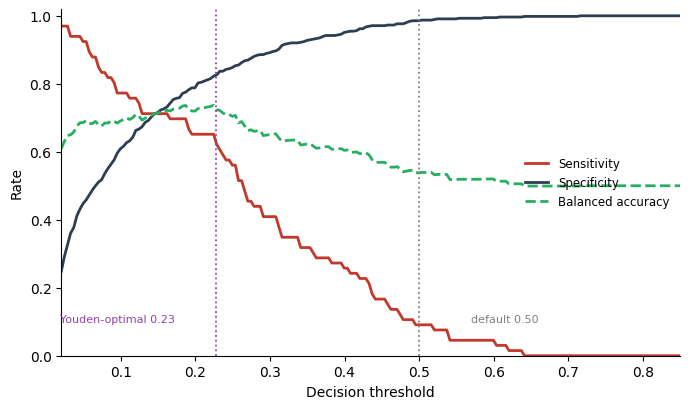

In [17]:
thrs = np.linspace(0.02, 0.85, 200)
yt = y_test.values
P, N = int(yt.sum()), int((yt == 0).sum())
sens_curve, spec_curve, bal_curve = [], [], []
for t in thrs:
    pred = (proba >= t).astype(int)
    tp = int(((pred == 1) & (yt == 1)).sum())
    tn = int(((pred == 0) & (yt == 0)).sum())
    s, sp = tp / P, tn / N
    sens_curve.append(s); spec_curve.append(sp); bal_curve.append((s + sp) / 2)

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(thrs, sens_curve, label="Sensitivity", color="#c0392b", lw=2)
ax.plot(thrs, spec_curve, label="Specificity", color="#2c3e50", lw=2)
ax.plot(thrs, bal_curve,  label="Balanced accuracy", color="#27ae60", lw=2, ls="--")
ax.axvline(0.50, color="grey", ls=":", lw=1.3)
ax.axvline(best_thr, color="#8e44ad", ls=":", lw=1.3)
ax.annotate("default 0.50", xy=(0.50, 0.05), xytext=(0.57, 0.10), fontsize=8, color="grey")
ax.annotate(f"Youden-optimal {best_thr:.2f}", xy=(best_thr, 0.05),
            xytext=(best_thr - 0.21, 0.10), fontsize=8, color="#8e44ad")
ax.set_xlabel("Decision threshold"); ax.set_ylabel("Rate")
ax.set_xlim(0.02, 0.85); ax.set_ylim(0, 1.02)
ax.legend(frameon=False, fontsize=8.5, loc="center right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("figures/threshold_sweep.png", dpi=300, bbox_inches="tight")
plt.show()

### Figure: sensitivity before vs after correction